# Intelligent Student Performance Assessment — Oversampled Model
**Student:** Nathan Bvumbwe | **Reg:** BSDS0322 | **Mzuzu University — ICT Department**

### Purpose of this notebook
The improved pipeline produced a behavioural model with F1=0.73 macro, but the
**Repeat band was severely underrepresented** in training (only 6.4% of samples).
This causes the model to under-detect at-risk students — the most critical failure
mode for a proactive intervention system.

This notebook applies **SMOTE (Synthetic Minority Over-sampling Technique)** to
the training set only, giving every band equal representation during training.
The test set is kept untouched so results are comparable and honest.

All outputs are saved separately:
- Models → `../model_oversampled/`
- Reports → `../report_assets_oversampled/`

This notebook is self-contained — it does not depend on the improved notebook.

## Stage 0 — Install Dependencies

In [1]:
# # Install imbalanced-learn (provides SMOTE) and pin numpy<2 for SHAP compatibility
# import subprocess, sys

# packages = [
#     ('numpy<2',           'numpy'),
#     ('imbalanced-learn',  'imblearn'),
#     ('shap',              'shap'),
#     ('scikit-learn',      'sklearn'),
#     ('pandas',            'pandas'),
#     ('matplotlib',        'matplotlib'),
#     ('seaborn',           'seaborn'),
#     ('joblib',            'joblib'),
# ]

# for pkg, _ in packages:
#     subprocess.run(
#         [sys.executable, '-m', 'pip', 'install', pkg, '--quiet', '--upgrade'],
#         check=False   # don't abort if one upgrade is blocked
#     )

# import numpy as np, shap, imblearn
# print(f'NumPy           : {np.__version__}')
# print(f'SHAP            : {shap.__version__}')
# print(f'imbalanced-learn: {imblearn.__version__}')
# print('Environment ready.')

## Stage 1 — Imports & Configuration

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import shap
import joblib
import os
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import (
    train_test_split, StratifiedKFold,
    cross_val_score, GridSearchCV
)
from sklearn.metrics import (
    classification_report, confusion_matrix,
    ConfusionMatrixDisplay, f1_score
)
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline
from collections import Counter

# ── Paths ────────────────────────────────────────────────────────────────
DATA_PATH  = '../data/student_performance_dataset_bigger.csv'
MODEL_DIR  = '../model_oversampled/'
REPORT_DIR = '../report_assets_oversampled/'
os.makedirs(MODEL_DIR,  exist_ok=True)
os.makedirs(REPORT_DIR, exist_ok=True)

# ── Band definitions ─────────────────────────────────────────────────────
BAND_ORDER  = ['Repeat', 'Supplementary', 'Good', 'Excellent']
BAND_TO_INT = {b: i for i, b in enumerate(BAND_ORDER)}
INT_TO_BAND = {i: b for i, b in enumerate(BAND_ORDER)}
PALETTE     = {
    'Repeat':        '#E24B4A',
    'Supplementary': '#EF9F27',
    'Good':          '#1D9E75',
    'Excellent':     '#534AB7',
}

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams.update({'figure.dpi': 150, 'font.size': 11})

print('Imports OK.')
print(f'Model artefacts → {os.path.abspath(MODEL_DIR)}')
print(f'Report assets   → {os.path.abspath(REPORT_DIR)}')


A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.4.4 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "c:\Users\user\anaconda3\envs\student_perf_env\Lib\site-packages\ipykernel_launcher.py", line 18, in <module>
    app.launch_new_instance()
  File "c:\Users\user\anaconda3\envs\student_perf_env\Lib\site-packages\traitlets\config\application.py", line 1075, in launch_instance
    app.start()
  File "c:\Users\user\anaconda3\envs\student_perf_env\Lib\site-packages\ipykernel\kernelapp.py", line 758, in start
    self

AttributeError: _ARRAY_API not found

Imports OK.
Model artefacts → c:\Users\user\Desktop\FORTH YEAR ASSIGNMENTS\FINAL YEAR PROJECT\student_perfomance_system\model_oversampled
Report assets   → c:\Users\user\Desktop\FORTH YEAR ASSIGNMENTS\FINAL YEAR PROJECT\student_perfomance_system\report_assets_oversampled


## Stage 2 — Load Data & Apply Layer 1

In [3]:
print('Loading dataset...')
df = pd.read_csv(DATA_PATH).reset_index(drop=True)
print(f'Shape: {df.shape[0]:,} rows × {df.shape[1]} columns')

# ── Layer 1: rule-based band assignment ─────────────────────────────────
def assign_mzuni_band(score: float) -> str:
    """Deterministic rule engine. Always matches Mzuni policy."""
    if   score <= 34: return 'Repeat'
    elif score <= 44: return 'Supplementary'
    elif score <= 64: return 'Good'
    else:             return 'Excellent'

df['mzuni_band']     = df['exam_score'].apply(assign_mzuni_band)
df['mzuni_band_int'] = df['mzuni_band'].map(BAND_TO_INT)

print('\n=== Layer 1: Band Distribution (original) ===')
band_counts = df['mzuni_band'].value_counts().reindex(BAND_ORDER)
for band, count in band_counts.items():
    pct = count / len(df) * 100
    print(f'  {band:<15}: {count:>8,}  ({pct:5.1f}%)')

Loading dataset...
Shape: 1,000,000 rows × 9 columns

=== Layer 1: Band Distribution (original) ===
  Repeat         :   64,251  (  6.4%)
  Supplementary  :  151,658  ( 15.2%)
  Good           :  357,505  ( 35.8%)
  Excellent      :  426,586  ( 42.7%)


## Stage 3 — Feature Engineering

In [4]:
RAW_BEHAV = ['study_hours_per_day', 'attendance_percentage',
             'sleep_hours', 'internet_usage_hours']

# Engineered features (same as improved notebook)
df['study_x_attendance'] = df['study_hours_per_day'] * df['attendance_percentage'] / 100
df['distraction_ratio']  = (df['internet_usage_hours'] / (df['study_hours_per_day'] + 0.1)).clip(upper=10)

study_norm    = df['study_hours_per_day']   / df['study_hours_per_day'].max()
attend_norm   = df['attendance_percentage'] / 100
internet_norm = df['internet_usage_hours']  / df['internet_usage_hours'].max()
df['risk_score'] = (1 - study_norm)*0.4 + (1 - attend_norm)*0.4 + internet_norm*0.2

# Store max values for inference-time feature engineering
FEAT_MAXES = {
    'study_hours_per_day':  df['study_hours_per_day'].max(),
    'internet_usage_hours': df['internet_usage_hours'].max(),
}
joblib.dump(FEAT_MAXES, f'{MODEL_DIR}feat_maxes.pkl')

ENGINEERED    = ['study_x_attendance', 'distraction_ratio', 'risk_score']
BEHAV_FEATURES = RAW_BEHAV + ENGINEERED
ALL_FEATURES   = BEHAV_FEATURES + ['exam_score']

print(f'Behavioural features ({len(BEHAV_FEATURES)}): {BEHAV_FEATURES}')
print(f'Full features        ({len(ALL_FEATURES)}): {ALL_FEATURES}')

Behavioural features (7): ['study_hours_per_day', 'attendance_percentage', 'sleep_hours', 'internet_usage_hours', 'study_x_attendance', 'distraction_ratio', 'risk_score']
Full features        (8): ['study_hours_per_day', 'attendance_percentage', 'sleep_hours', 'internet_usage_hours', 'study_x_attendance', 'distraction_ratio', 'risk_score', 'exam_score']


## Stage 4 — Train/Test Split (test set kept imbalanced — original distribution)

In [5]:
# IMPORTANT: split BEFORE oversampling.
# SMOTE is only applied to the training set.
# The test set reflects the real-world class distribution.
y = df['mzuni_band_int']

X_all_tr, X_all_te, y_train, y_test = train_test_split(
    df[ALL_FEATURES], y,
    test_size=0.2, random_state=42, stratify=y
)
X_beh_tr = df[BEHAV_FEATURES].loc[X_all_tr.index]
X_beh_te = df[BEHAV_FEATURES].loc[X_all_te.index]

print(f'Train : {len(X_all_tr):,} samples')
print(f'Test  : {len(X_all_te):,} samples  (original distribution — untouched)')
print(f'\nTrain class distribution BEFORE oversampling:')
c = Counter(y_train)
for i, b in enumerate(BAND_ORDER):
    n = c[i]
    print(f'  {b:<15}: {n:>8,}  ({n/len(y_train)*100:.1f}%)')

Train : 800,000 samples
Test  : 200,000 samples  (original distribution — untouched)

Train class distribution BEFORE oversampling:
  Repeat         :   51,401  (6.4%)
  Supplementary  :  121,326  (15.2%)
  Good           :  286,004  (35.8%)
  Excellent      :  341,269  (42.7%)


## Stage 5 — SMOTE Oversampling

SMOTE (Synthetic Minority Over-sampling Technique) creates synthetic samples
for the minority classes by interpolating between existing examples in feature space.
It is applied only to the training set so evaluation remains honest.

We use a **sampling strategy that brings all classes to equal representation**,
matching the Excellent class count (the majority class in training).

In [6]:
# ── Apply SMOTE to behavioural features (training only) ─────────────────
# k_neighbors=5 is the standard default.
# random_state fixed for reproducibility.
smote = SMOTE(sampling_strategy='auto', k_neighbors=5, random_state=42)

print('Applying SMOTE to behavioural training set...')
X_beh_tr_sm, y_train_sm = smote.fit_resample(X_beh_tr, y_train)

print(f'\nBehavioural train BEFORE: {len(X_beh_tr):,} samples')
print(f'Behavioural train AFTER : {len(X_beh_tr_sm):,} samples')
print(f'\nClass distribution AFTER oversampling:')
c_sm = Counter(y_train_sm)
for i, b in enumerate(BAND_ORDER):
    n = c_sm[i]
    print(f'  {b:<15}: {n:>8,}  ({n/len(y_train_sm)*100:.1f}%)')

# ── Apply SMOTE to full feature set too (for full model comparison) ──────
print('\nApplying SMOTE to full feature training set...')
X_all_tr_sm, y_train_sm_full = smote.fit_resample(X_all_tr, y_train)
print(f'Full train AFTER: {len(X_all_tr_sm):,} samples')

Applying SMOTE to behavioural training set...

Behavioural train BEFORE: 800,000 samples
Behavioural train AFTER : 1,365,076 samples

Class distribution AFTER oversampling:
  Repeat         :  341,269  (25.0%)
  Supplementary  :  341,269  (25.0%)
  Good           :  341,269  (25.0%)
  Excellent      :  341,269  (25.0%)

Applying SMOTE to full feature training set...
Full train AFTER: 1,365,076 samples


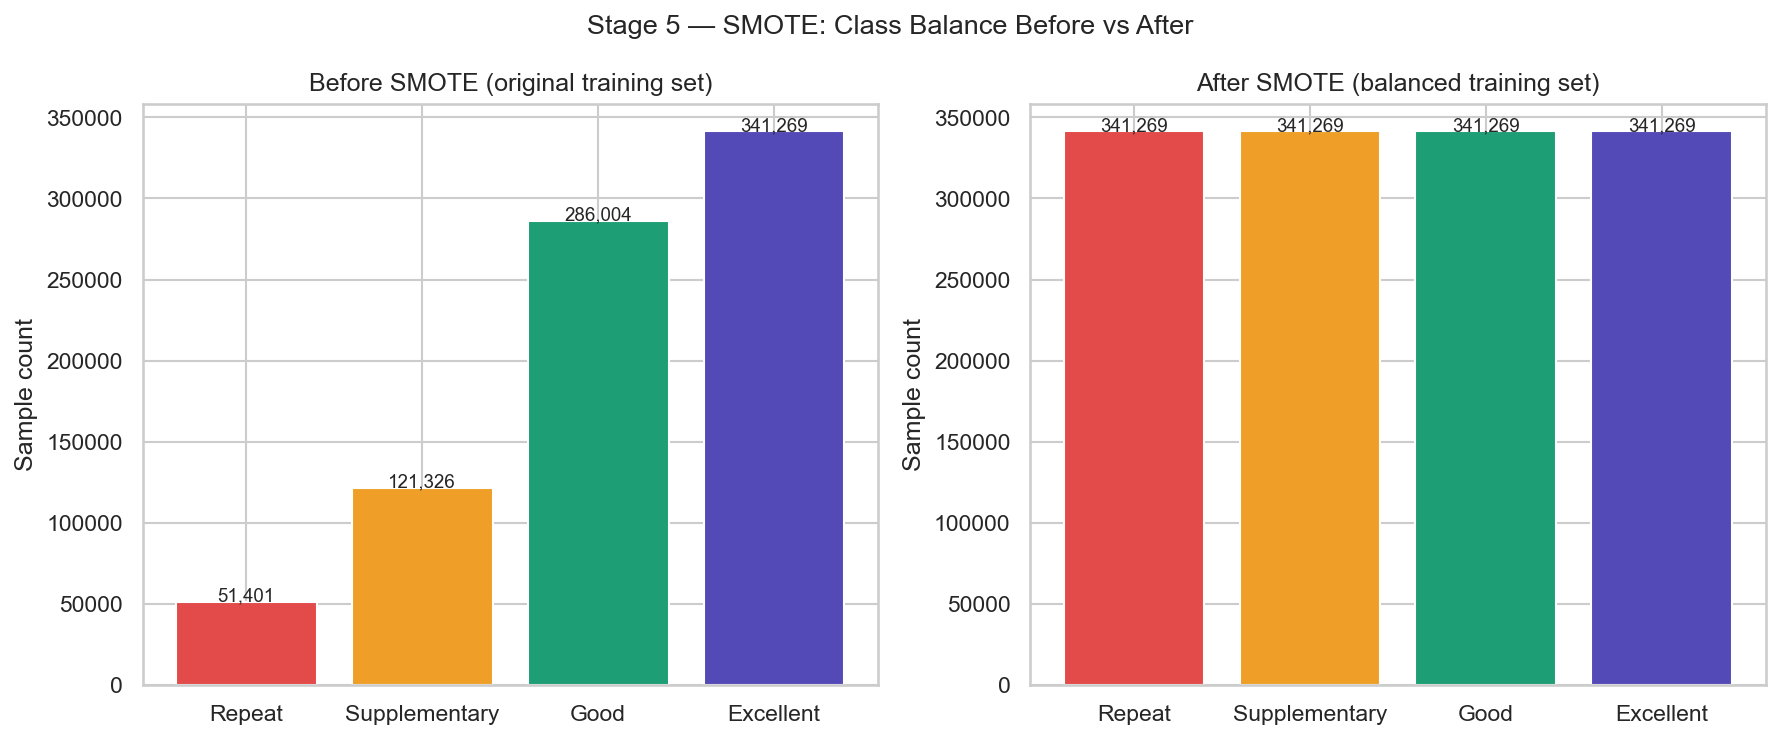

Saved: 01_smote_balance.png


In [7]:
# ── Visualise class balance before vs after ──────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

before_counts = [Counter(y_train)[i] for i in range(4)]
after_counts  = [Counter(y_train_sm)[i] for i in range(4)]
colors        = [PALETTE[b] for b in BAND_ORDER]

axes[0].bar(BAND_ORDER, before_counts, color=colors, edgecolor='white')
axes[0].set_title('Before SMOTE (original training set)')
axes[0].set_ylabel('Sample count')
for i, v in enumerate(before_counts):
    axes[0].text(i, v + 500, f'{v:,}', ha='center', fontsize=9)

axes[1].bar(BAND_ORDER, after_counts, color=colors, edgecolor='white')
axes[1].set_title('After SMOTE (balanced training set)')
axes[1].set_ylabel('Sample count')
for i, v in enumerate(after_counts):
    axes[1].text(i, v + 500, f'{v:,}', ha='center', fontsize=9)

plt.suptitle('Stage 5 — SMOTE: Class Balance Before vs After', fontsize=13)
plt.tight_layout()
plt.savefig(f'{REPORT_DIR}01_smote_balance.png', bbox_inches='tight')
plt.show()
print('Saved: 01_smote_balance.png')

## Stage 6 — Full Model (oversampled)

Same architecture as the improved notebook but trained on the SMOTE-balanced data.

In [8]:
print('Training full model on SMOTE-balanced data...')
rf_full_sm = RandomForestClassifier(
    n_estimators=200,
    max_depth=15,
    min_samples_leaf=5,
    max_features='sqrt',
    random_state=42,
    n_jobs=-1,
    # No class_weight='balanced' needed — SMOTE already balances at data level
)
rf_full_sm.fit(X_all_tr_sm, y_train_sm_full)

cv_full_sm = cross_val_score(
    rf_full_sm, X_all_tr_sm, y_train_sm_full,
    cv=StratifiedKFold(5, shuffle=True, random_state=42),
    scoring='f1_macro', n_jobs=-1
)
print(f'5-Fold CV F1 (macro): {cv_full_sm.mean():.4f} ± {cv_full_sm.std():.4f}')

y_pred_full_sm = rf_full_sm.predict(X_all_te)
f1_full_sm = f1_score(y_test, y_pred_full_sm, average='macro')

print(f'\n=== Full Model (oversampled) — Test Set Report ===')
print(classification_report(y_test, y_pred_full_sm, target_names=BAND_ORDER))

joblib.dump(rf_full_sm, f'{MODEL_DIR}rf_full_model.pkl')
size_kb = os.path.getsize(f'{MODEL_DIR}rf_full_model.pkl') / 1024
print(f'Saved rf_full_model.pkl  ({size_kb:.0f} KB)')

Training full model on SMOTE-balanced data...
5-Fold CV F1 (macro): 1.0000 ± 0.0000

=== Full Model (oversampled) — Test Set Report ===
               precision    recall  f1-score   support

       Repeat       1.00      1.00      1.00     12850
Supplementary       1.00      1.00      1.00     30332
         Good       1.00      1.00      1.00     71501
    Excellent       1.00      1.00      1.00     85317

     accuracy                           1.00    200000
    macro avg       1.00      1.00      1.00    200000
 weighted avg       1.00      1.00      1.00    200000

Saved rf_full_model.pkl  (39660 KB)


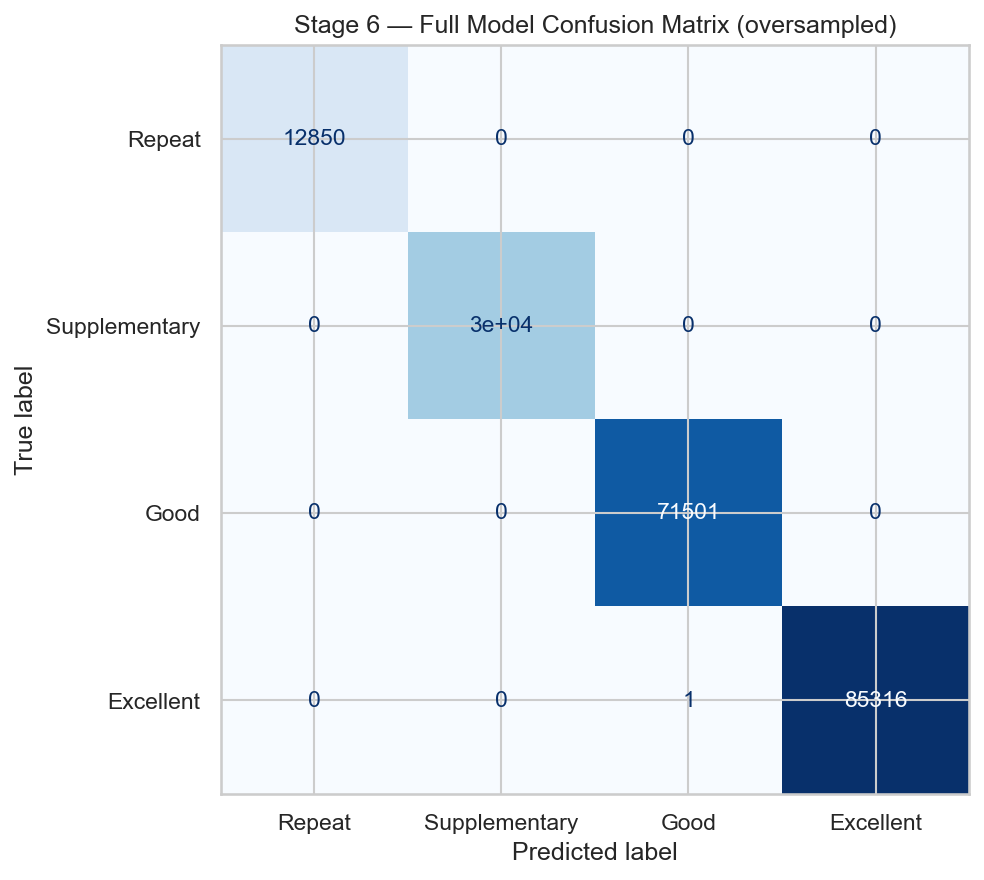

Saved: 02_confusion_full.png


In [9]:
fig, ax = plt.subplots(figsize=(7, 6))
ConfusionMatrixDisplay(
    confusion_matrix(y_test, y_pred_full_sm),
    display_labels=BAND_ORDER
).plot(ax=ax, cmap='Blues', colorbar=False)
ax.set_title('Stage 6 — Full Model Confusion Matrix (oversampled)')
plt.tight_layout()
plt.savefig(f'{REPORT_DIR}02_confusion_full.png', bbox_inches='tight')
plt.show()
print('Saved: 02_confusion_full.png')

## Stage 7 — Behavioural Model: GridSearchCV + Compress (oversampled)

This is the critical model — early warning with no exam score.
SMOTE should most improve Repeat detection here.

In [10]:
# ── Baseline on original (imbalanced) data — for comparison ─────────────
print('Baseline behavioural model (original imbalanced data)...')
rf_base = RandomForestClassifier(
    n_estimators=100, max_depth=10, min_samples_leaf=10,
    max_features='sqrt', random_state=42, n_jobs=-1, class_weight='balanced'
)
rf_base.fit(X_beh_tr, y_train)
y_pred_base = rf_base.predict(X_beh_te)
f1_base = f1_score(y_test, y_pred_base, average='macro')
recall_repeat_base = classification_report(
    y_test, y_pred_base, target_names=BAND_ORDER, output_dict=True
)['Repeat']['recall']

print(f'Baseline F1 (macro)   : {f1_base:.4f}')
print(f'Baseline Repeat recall: {recall_repeat_base:.4f}')
print(classification_report(y_test, y_pred_base, target_names=BAND_ORDER))

Baseline behavioural model (original imbalanced data)...
Baseline F1 (macro)   : 0.7327
Baseline Repeat recall: 0.7595
               precision    recall  f1-score   support

       Repeat       0.55      0.76      0.64     12850
Supplementary       0.56      0.64      0.60     30332
         Good       0.82      0.74      0.78     71501
    Excellent       0.93      0.91      0.92     85317

     accuracy                           0.80    200000
    macro avg       0.72      0.76      0.73    200000
 weighted avg       0.81      0.80      0.80    200000



In [11]:
# ── GridSearchCV on SMOTE-balanced data ─────────────────────────────────
# Subsample the balanced set for speed (20k still proportionally representative
# since all classes are equal after SMOTE)
print('Running GridSearchCV on SMOTE-balanced data (~5 minutes)...')

gs_idx  = pd.Series(range(len(X_beh_tr_sm))).sample(20_000, random_state=42).values
X_gs    = X_beh_tr_sm.iloc[gs_idx] if hasattr(X_beh_tr_sm, 'iloc') else X_beh_tr_sm[gs_idx]
y_gs    = y_train_sm.iloc[gs_idx]  if hasattr(y_train_sm,  'iloc') else y_train_sm[gs_idx]

param_grid = {
    'n_estimators':     [100, 200],
    'max_depth':        [10, 15, 20],
    'min_samples_leaf': [5, 10, 20],
    'max_features':     ['sqrt', 'log2'],
}

gs = GridSearchCV(
    RandomForestClassifier(random_state=42, n_jobs=-1),
    param_grid,
    cv=StratifiedKFold(3, shuffle=True, random_state=42),
    scoring='f1_macro',
    n_jobs=-1,
    verbose=1,
)
gs.fit(X_gs, y_gs)

print(f'\nBest params : {gs.best_params_}')
print(f'Best CV F1  : {gs.best_score_:.4f}')

Running GridSearchCV on SMOTE-balanced data (~5 minutes)...
Fitting 3 folds for each of 36 candidates, totalling 108 fits

Best params : {'max_depth': 20, 'max_features': 'sqrt', 'min_samples_leaf': 20, 'n_estimators': 200}
Best CV F1  : 0.7619


In [12]:
# ── Retrain tuned model on full SMOTE training set ───────────────────────
best_params = gs.best_params_
print(f'Retraining tuned model on full SMOTE training set...')
print(f'Params: {best_params}')

rf_tuned_sm = RandomForestClassifier(
    **best_params,
    random_state=42,
    n_jobs=-1,
)
rf_tuned_sm.fit(X_beh_tr_sm, y_train_sm)
y_pred_tuned = rf_tuned_sm.predict(X_beh_te)
f1_tuned = f1_score(y_test, y_pred_tuned, average='macro')
recall_repeat_tuned = classification_report(
    y_test, y_pred_tuned, target_names=BAND_ORDER, output_dict=True
)['Repeat']['recall']

print(f'\nTuned SMOTE F1 (macro)   : {f1_tuned:.4f}')
print(f'Tuned SMOTE Repeat recall: {recall_repeat_tuned:.4f}')
print(f'Recall improvement (Repeat): +{(recall_repeat_tuned - recall_repeat_base)*100:.2f}%')
print()
print(classification_report(y_test, y_pred_tuned, target_names=BAND_ORDER))

Retraining tuned model on full SMOTE training set...
Params: {'max_depth': 20, 'max_features': 'sqrt', 'min_samples_leaf': 20, 'n_estimators': 200}

Tuned SMOTE F1 (macro)   : 0.7379
Tuned SMOTE Repeat recall: 0.6815
Recall improvement (Repeat): +-7.81%

               precision    recall  f1-score   support

       Repeat       0.58      0.68      0.63     12850
Supplementary       0.59      0.65      0.62     30332
         Good       0.81      0.77      0.79     71501
    Excellent       0.92      0.91      0.92     85317

     accuracy                           0.80    200000
    macro avg       0.73      0.75      0.74    200000
 weighted avg       0.81      0.80      0.81    200000



In [13]:
# ── Compress: smallest model keeping >95% of tuned F1 ───────────────────
target_f1 = f1_tuned * 0.95
print(f'Tuned F1: {f1_tuned:.4f}  |  Target (95%): {target_f1:.4f}\n')

compression_results = []
for n_trees in [25, 50, 75, 100]:
    rf_s = RandomForestClassifier(
        n_estimators=n_trees,
        max_depth=best_params['max_depth'],
        min_samples_leaf=best_params['min_samples_leaf'],
        max_features=best_params['max_features'],
        random_state=42, n_jobs=-1
    )
    rf_s.fit(X_beh_tr_sm, y_train_sm)
    preds  = rf_s.predict(X_beh_te)
    f1_s   = f1_score(y_test, preds, average='macro')
    tmp    = f'{MODEL_DIR}_tmp.pkl'
    joblib.dump(rf_s, tmp)
    kb     = os.path.getsize(tmp) / 1024
    os.remove(tmp)
    ok     = f1_s >= target_f1
    compression_results.append({'n_trees':n_trees,'f1_macro':round(f1_s,4),
                                 'size_kb':round(kb,0),'meets_target':ok})
    print(f'  {n_trees:>3} trees  F1={f1_s:.4f}  {kb:>8.0f} KB  {"✓" if ok else "✗"}')

comp_df    = pd.DataFrame(compression_results)
candidates = comp_df[comp_df['meets_target']]
best_row   = candidates.loc[candidates['size_kb'].idxmin()]
BEST_N_TREES = int(best_row['n_trees'])
print(f'\nSelected: {BEST_N_TREES} trees  (F1={best_row["f1_macro"]},  size={best_row["size_kb"]:.0f} KB)')

Tuned F1: 0.7379  |  Target (95%): 0.7010

   25 trees  F1=0.7360     93542 KB  ✓
   50 trees  F1=0.7363    184329 KB  ✓
   75 trees  F1=0.7368    276177 KB  ✓
  100 trees  F1=0.7370    368883 KB  ✓

Selected: 25 trees  (F1=0.736,  size=93542 KB)


In [14]:
# ── Train final compressed model on SMOTE data ───────────────────────────
print(f'Training final compressed model ({BEST_N_TREES} trees, SMOTE data)...')
rf_behav_final = RandomForestClassifier(
    n_estimators=BEST_N_TREES,
    max_depth=best_params['max_depth'],
    min_samples_leaf=best_params['min_samples_leaf'],
    max_features=best_params['max_features'],
    random_state=42, n_jobs=-1
)
rf_behav_final.fit(X_beh_tr_sm, y_train_sm)
y_pred_final  = rf_behav_final.predict(X_beh_te)
f1_final      = f1_score(y_test, y_pred_final, average='macro')
report_final  = classification_report(
    y_test, y_pred_final, target_names=BAND_ORDER, output_dict=True
)
recall_repeat_final = report_final['Repeat']['recall']

joblib.dump(rf_behav_final, f'{MODEL_DIR}rf_behav_model.pkl')
size_final = os.path.getsize(f'{MODEL_DIR}rf_behav_model.pkl') / 1024

print(f'  F1 (macro)    : {f1_final:.4f}')
print(f'  Repeat recall : {recall_repeat_final:.4f}')
print(f'  Size          : {size_final:.0f} KB  ({size_final/1024:.1f} MB)')
print()
print(classification_report(y_test, y_pred_final, target_names=BAND_ORDER))

Training final compressed model (25 trees, SMOTE data)...
  F1 (macro)    : 0.7360
  Repeat recall : 0.6813
  Size          : 93542 KB  (91.3 MB)

               precision    recall  f1-score   support

       Repeat       0.58      0.68      0.63     12850
Supplementary       0.59      0.64      0.61     30332
         Good       0.81      0.77      0.79     71501
    Excellent       0.93      0.91      0.92     85317

     accuracy                           0.80    200000
    macro avg       0.72      0.75      0.74    200000
 weighted avg       0.81      0.80      0.81    200000



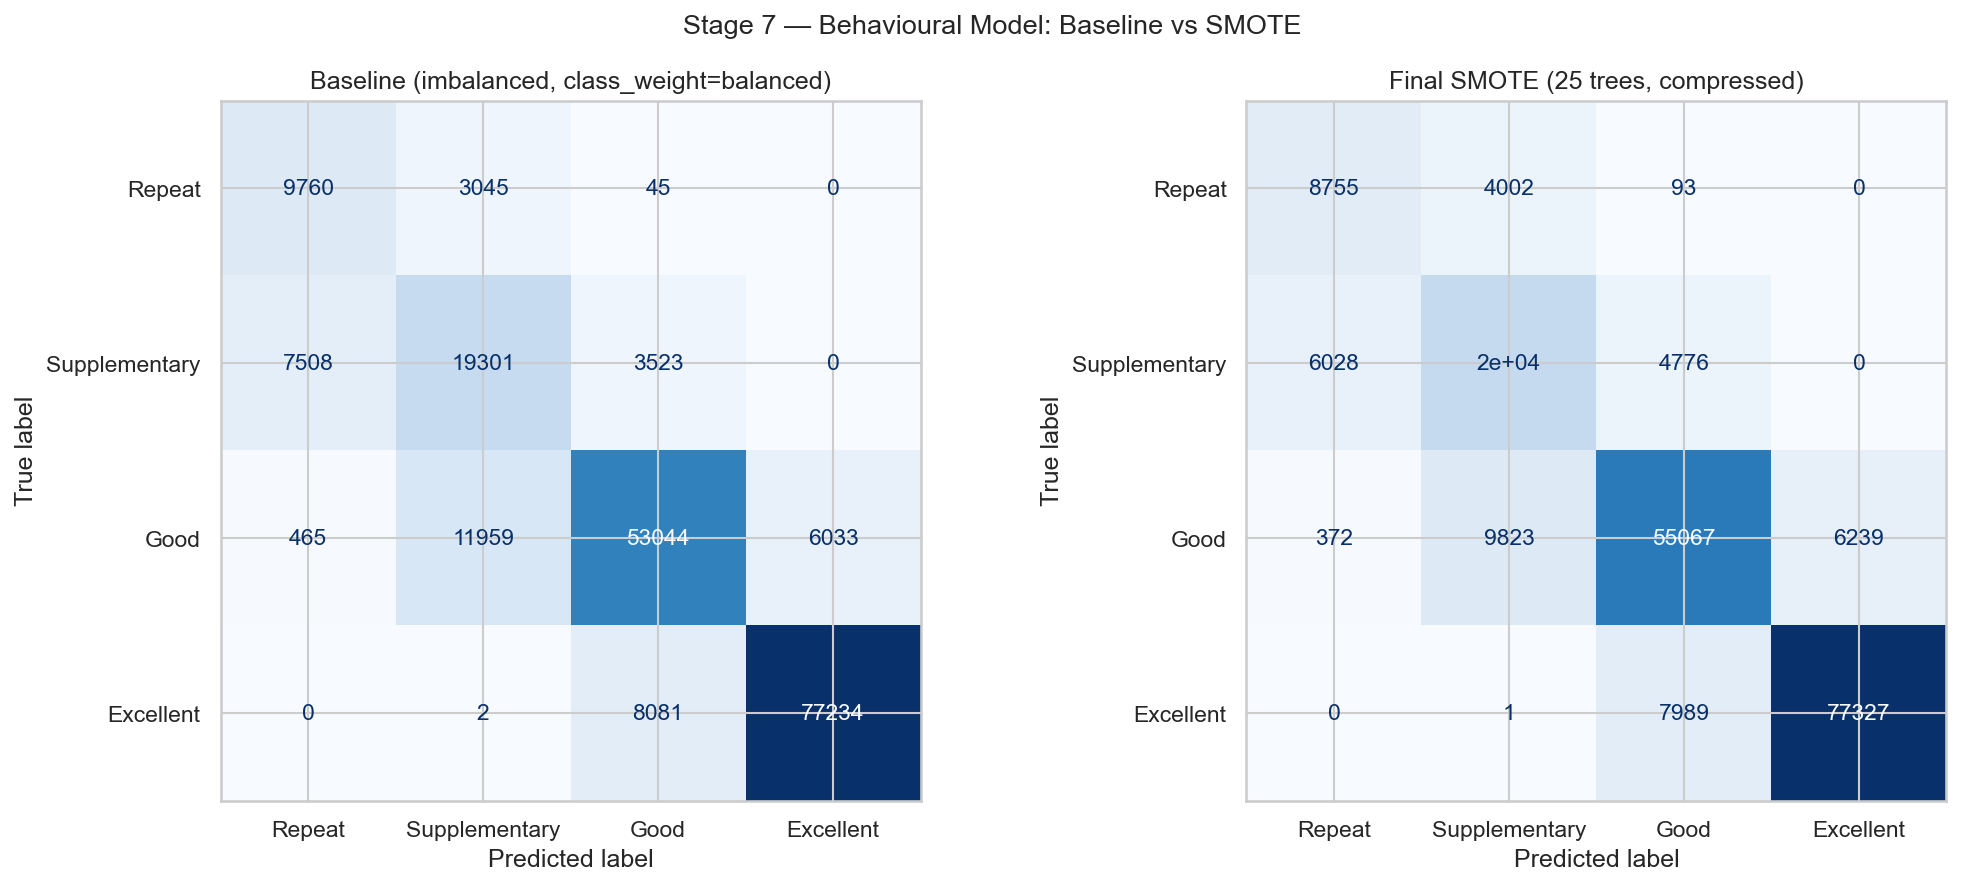

Saved: 03_confusion_behav_comparison.png


In [15]:
# ── Confusion matrix comparison: baseline vs oversampled ─────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
for ax, preds, title in [
    (axes[0], y_pred_base,  'Baseline (imbalanced, class_weight=balanced)'),
    (axes[1], y_pred_final, f'Final SMOTE ({BEST_N_TREES} trees, compressed)'),
]:
    ConfusionMatrixDisplay(
        confusion_matrix(y_test, preds),
        display_labels=BAND_ORDER
    ).plot(ax=ax, cmap='Blues', colorbar=False)
    ax.set_title(title)
plt.suptitle('Stage 7 — Behavioural Model: Baseline vs SMOTE', fontsize=13)
plt.tight_layout()
plt.savefig(f'{REPORT_DIR}03_confusion_behav_comparison.png', bbox_inches='tight')
plt.show()
print('Saved: 03_confusion_behav_comparison.png')

In [16]:
# ── Summary progression table ────────────────────────────────────────────
progression = pd.DataFrame([
    {'Model': 'Baseline (imbalanced)',
     'F1 macro': round(f1_base, 4),
     'Repeat recall': round(recall_repeat_base, 4),
     'Notes': 'class_weight=balanced, no SMOTE'},
    {'Model': 'Tuned SMOTE (full)',
     'F1 macro': round(f1_tuned, 4),
     'Repeat recall': round(recall_repeat_tuned, 4),
     'Notes': f'Best params: {best_params}'},
    {'Model': f'Final SMOTE ({BEST_N_TREES} trees)',
     'F1 macro': round(f1_final, 4),
     'Repeat recall': round(recall_repeat_final, 4),
     'Notes': f'{size_final:.0f} KB — app-ready'},
])
print('=== Behavioural Model Progression (oversampled) ===')
display(progression)
progression.to_csv(f'{REPORT_DIR}04_model_progression.csv', index=False)
print('Saved: 04_model_progression.csv')

=== Behavioural Model Progression (oversampled) ===


,Model,F1 macro,Repeat recall,Notes
0,Baseline (imbalanced),0.7327,0.7595,"class_weight=balanced, no SMOTE"
1,Tuned SMOTE (full),0.7379,0.6815,"Best params: {'max_depth': 20, 'max_features':..."
2,Final SMOTE (25 trees),0.7360,0.6813,93542 KB — app-ready


Saved: 04_model_progression.csv


## Stage 8 — Band Profiles & Visualisations

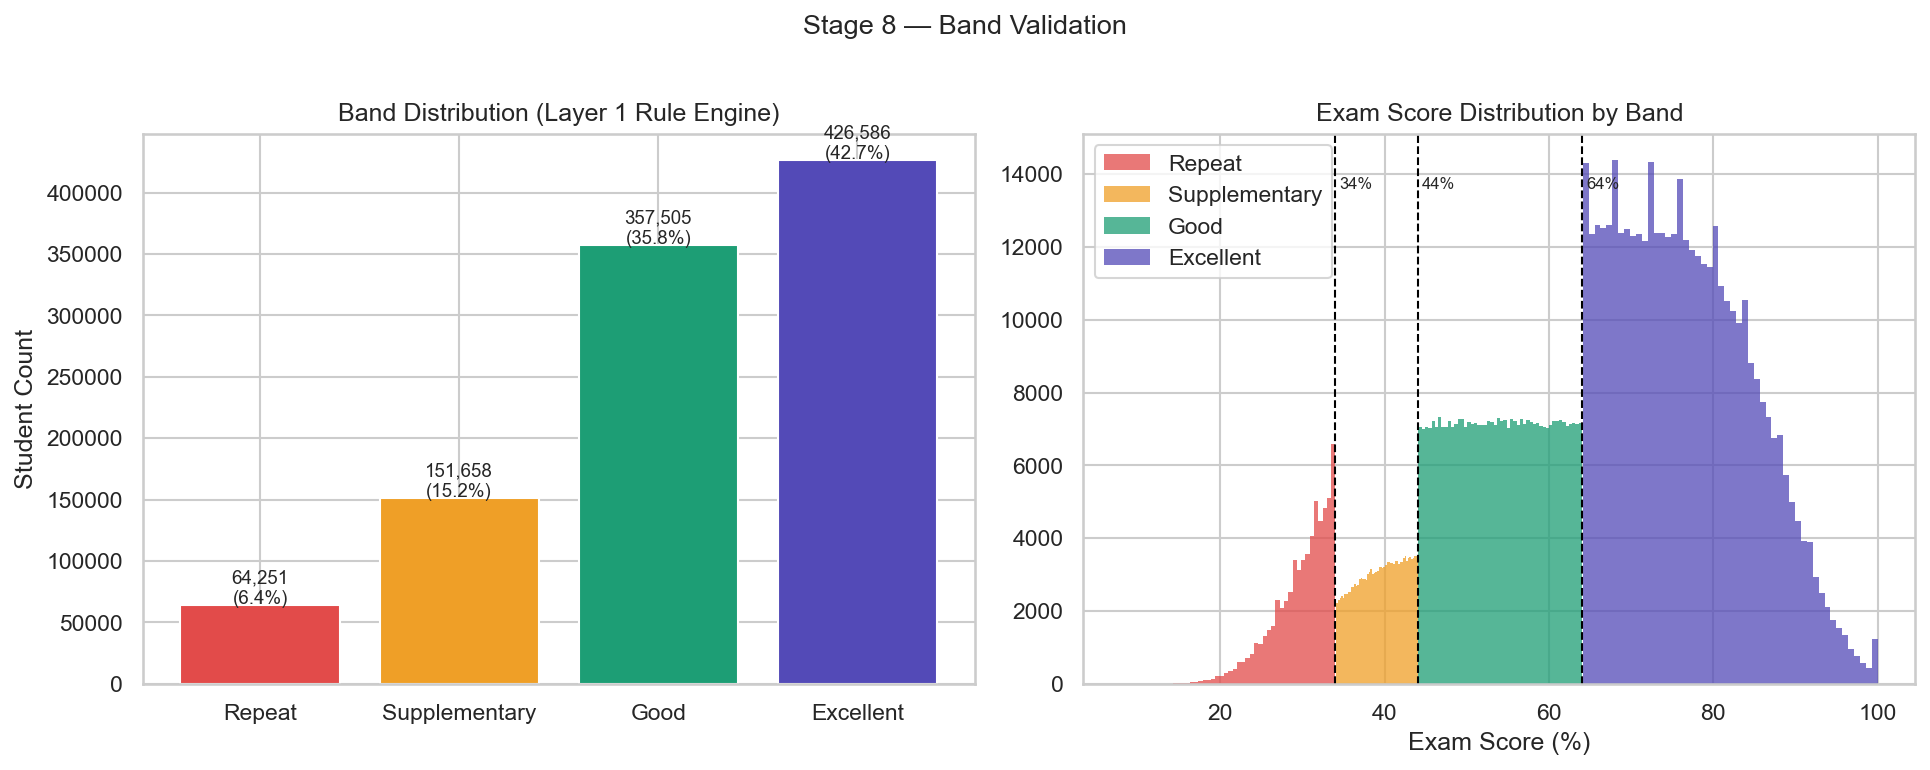

Saved: 05_band_distribution.png


In [17]:
band_counts = df['mzuni_band'].value_counts().reindex(BAND_ORDER)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].bar(BAND_ORDER, band_counts.values,
            color=[PALETTE[b] for b in BAND_ORDER], edgecolor='white')
axes[0].set_title('Band Distribution (Layer 1 Rule Engine)')
axes[0].set_ylabel('Student Count')
for i, v in enumerate(band_counts.values):
    axes[0].text(i, v + 1000, f'{v:,}\n({v/len(df)*100:.1f}%)', ha='center', fontsize=9)

for band in BAND_ORDER:
    axes[1].hist(df[df['mzuni_band']==band]['exam_score'],
                 bins=50, alpha=0.75, label=band,
                 color=PALETTE[band], edgecolor='none')
for thresh, lbl in [(34,'34%'),(44,'44%'),(64,'64%')]:
    axes[1].axvline(thresh, color='black', linestyle='--', linewidth=1)
    axes[1].text(thresh+0.5, axes[1].get_ylim()[1]*0.9, lbl, fontsize=8)
axes[1].set_title('Exam Score Distribution by Band')
axes[1].set_xlabel('Exam Score (%)')
axes[1].legend()

plt.suptitle('Stage 8 — Band Validation', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig(f'{REPORT_DIR}05_band_distribution.png', bbox_inches='tight')
plt.show()
print('Saved: 05_band_distribution.png')

,study_hours_per_day,attendance_percentage,sleep_hours,internet_usage_hours,study_x_attendance,distraction_ratio,risk_score,exam_score,count,% of total
mzuni_band,,,,,,,,,,
Repeat,1.53,72.93,6.5,3.5,1.11,2.28,0.55,29.76,64251,6.4
Supplementary,2.11,78.37,6.5,3.5,1.62,1.74,0.50,39.40,151658,15.2
Good,3.76,79.96,6.5,3.5,2.96,0.99,0.41,54.06,357505,35.8
Excellent,6.41,81.69,6.5,3.5,5.21,0.55,0.27,76.80,426586,42.7


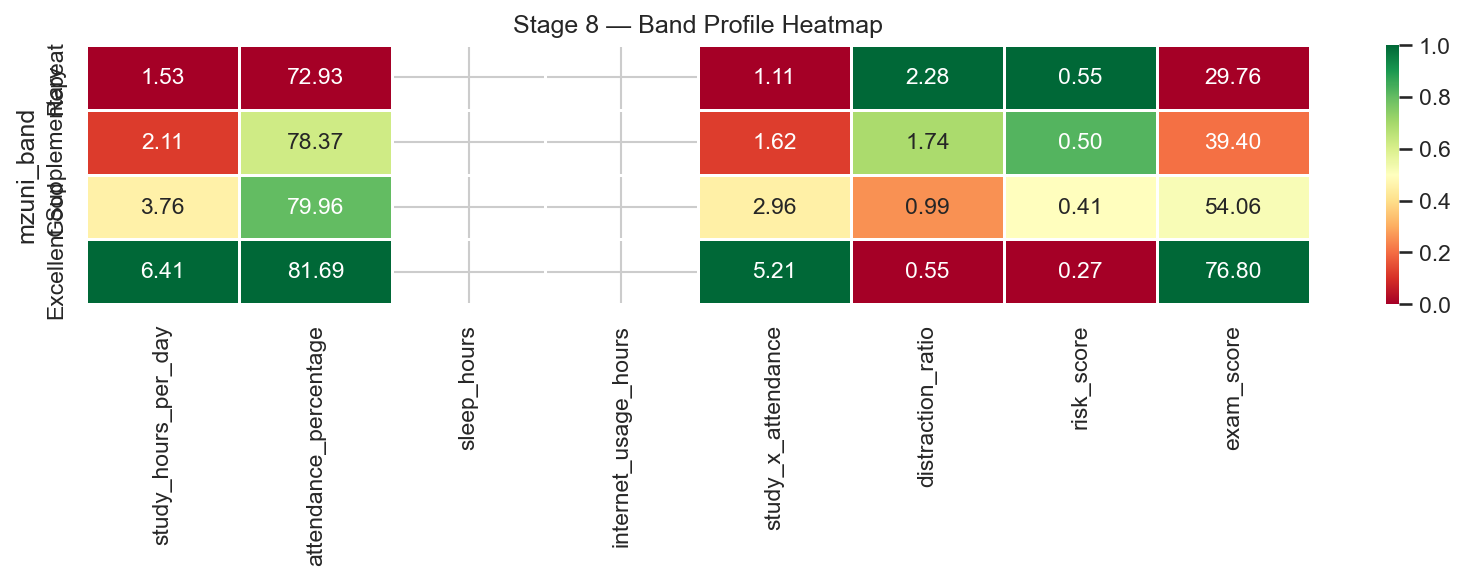

Saved: 05b_band_profiles.csv, 05c_band_heatmap.png


In [18]:
profile = df.groupby('mzuni_band')[ALL_FEATURES].mean().round(2).reindex(BAND_ORDER)
profile['count']      = df['mzuni_band'].value_counts().reindex(BAND_ORDER)
profile['% of total'] = (profile['count'] / len(df) * 100).round(1)
display(profile)
profile.to_csv(f'{REPORT_DIR}05b_band_profiles.csv')

profile_norm = (profile[ALL_FEATURES] - profile[ALL_FEATURES].min()) / \
               (profile[ALL_FEATURES].max() - profile[ALL_FEATURES].min())
fig, ax = plt.subplots(figsize=(11, 4))
sns.heatmap(profile_norm, annot=profile[ALL_FEATURES],
            fmt='.2f', cmap='RdYlGn', linewidths=0.5, ax=ax, vmin=0, vmax=1)
ax.set_title('Stage 8 — Band Profile Heatmap')
plt.tight_layout()
plt.savefig(f'{REPORT_DIR}05c_band_heatmap.png', bbox_inches='tight')
plt.show()
print('Saved: 05b_band_profiles.csv, 05c_band_heatmap.png')

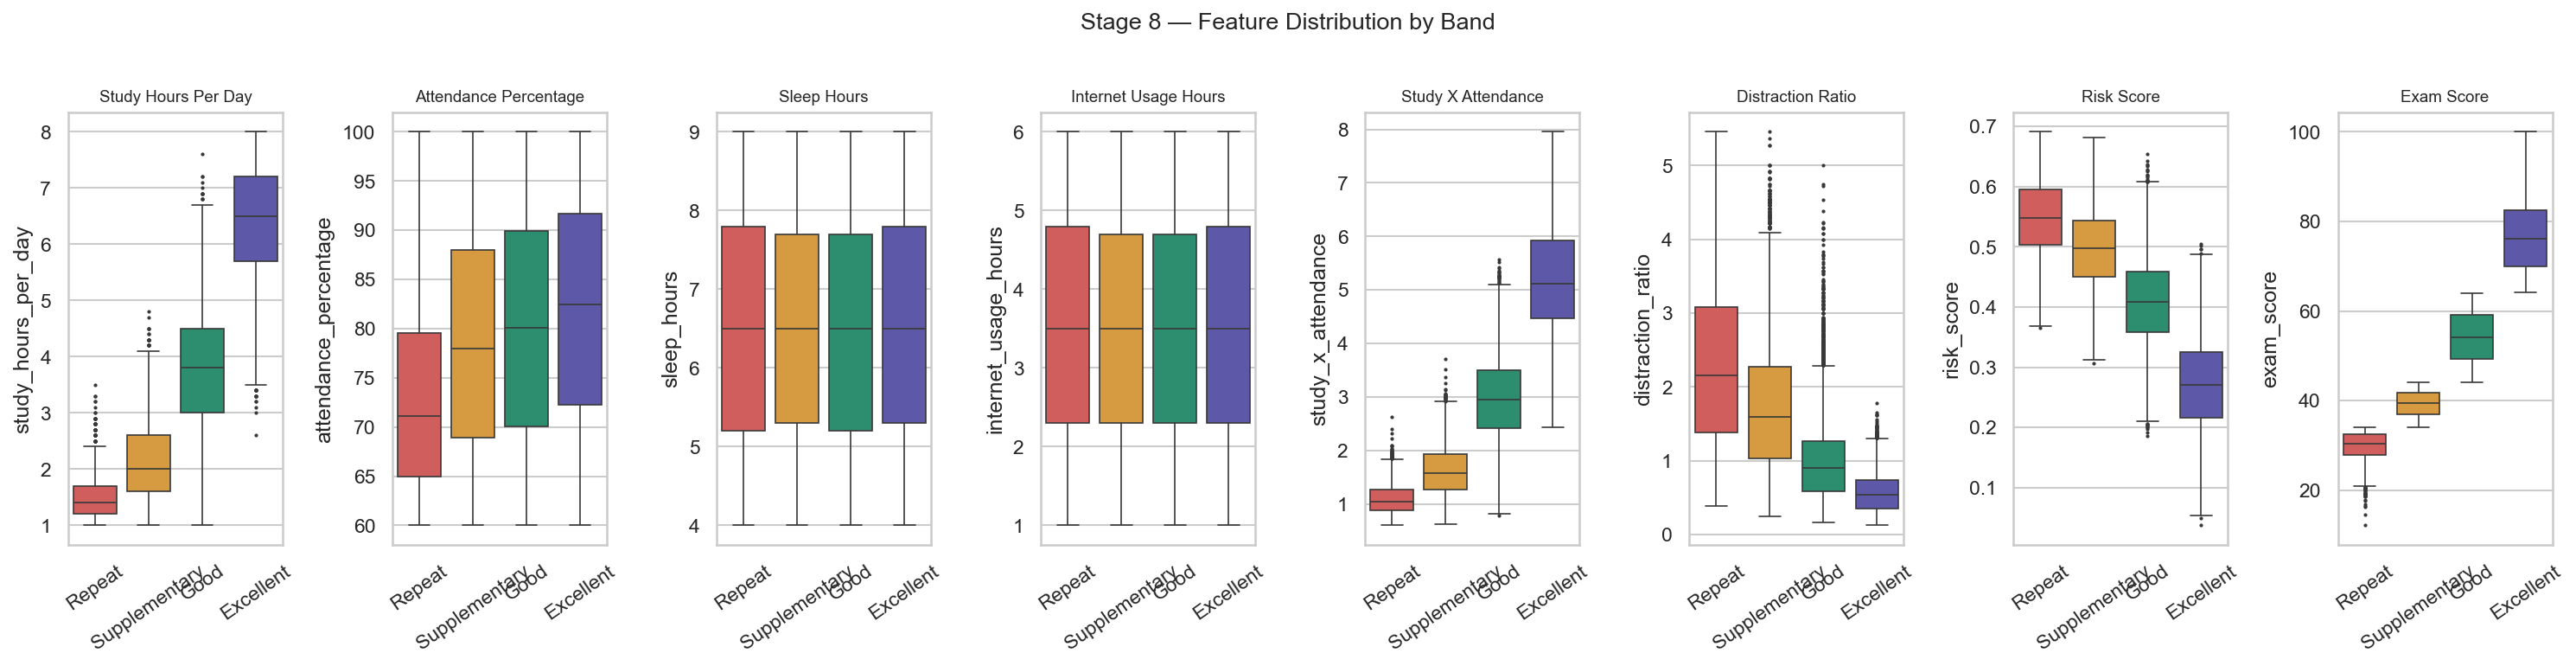

Saved: 05d_boxplots.png


In [19]:
fig, axes = plt.subplots(1, len(ALL_FEATURES), figsize=(20, 5))
for ax, col in zip(axes, ALL_FEATURES):
    sns.boxplot(data=df.sample(30_000, random_state=2),
                x='mzuni_band', y=col, order=BAND_ORDER,
                palette=PALETTE, ax=ax, linewidth=0.8, fliersize=1)
    ax.set_title(col.replace('_',' ').title(), fontsize=9)
    ax.set_xlabel('')
    ax.tick_params(axis='x', rotation=35)
plt.suptitle('Stage 8 — Feature Distribution by Band', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig(f'{REPORT_DIR}05d_boxplots.png', bbox_inches='tight')
plt.show()
print('Saved: 05d_boxplots.png')

## Stage 9 — SHAP Explainability

In [20]:
def normalise_shap(sv, n):
    if sv.ndim == 3 and sv.shape[0] == n: return sv
    if sv.ndim == 3 and sv.shape[0] == 4: return sv.transpose(1, 2, 0)
    raise ValueError(f'Unexpected SHAP shape: {sv.shape}')

shap_sample_all = X_all_te.sample(3000, random_state=42)
shap_sample_beh = X_beh_te.loc[shap_sample_all.index]

sv_full  = normalise_shap(np.array(shap.TreeExplainer(rf_full_sm).shap_values(shap_sample_all)), 3000)
sv_behav = normalise_shap(np.array(shap.TreeExplainer(rf_behav_final).shap_values(shap_sample_beh)), 3000)

print(f'Full SHAP  : {sv_full.shape}')
print(f'Behav SHAP : {sv_behav.shape}')

Full SHAP  : (3000, 8, 4)
Behav SHAP : (3000, 7, 4)


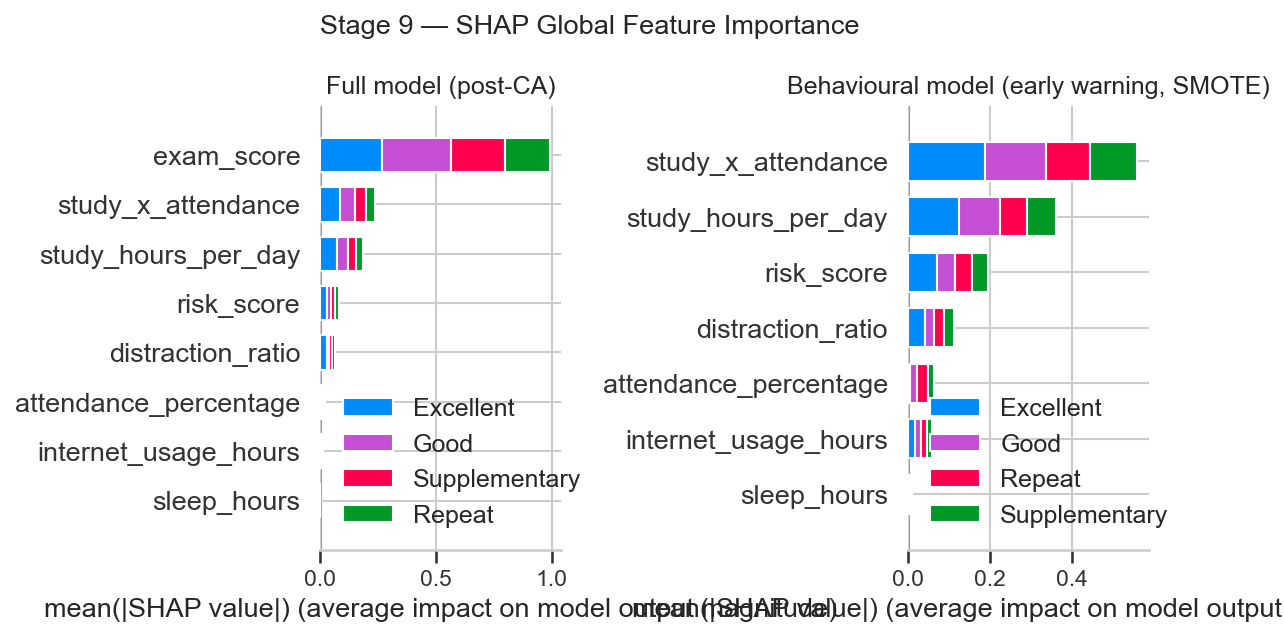

Saved: 06a_shap_global.png


In [21]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
plt.sca(axes[0])
shap.summary_plot(sv_full,  shap_sample_all, class_names=BAND_ORDER, plot_type='bar', show=False)
axes[0].set_title('Full model (post-CA)')
plt.sca(axes[1])
shap.summary_plot(sv_behav, shap_sample_beh, class_names=BAND_ORDER, plot_type='bar', show=False)
axes[1].set_title('Behavioural model (early warning, SMOTE)')
plt.suptitle('Stage 9 — SHAP Global Feature Importance', fontsize=13)
plt.tight_layout()
plt.savefig(f'{REPORT_DIR}06a_shap_global.png', bbox_inches='tight')
plt.show()
print('Saved: 06a_shap_global.png')

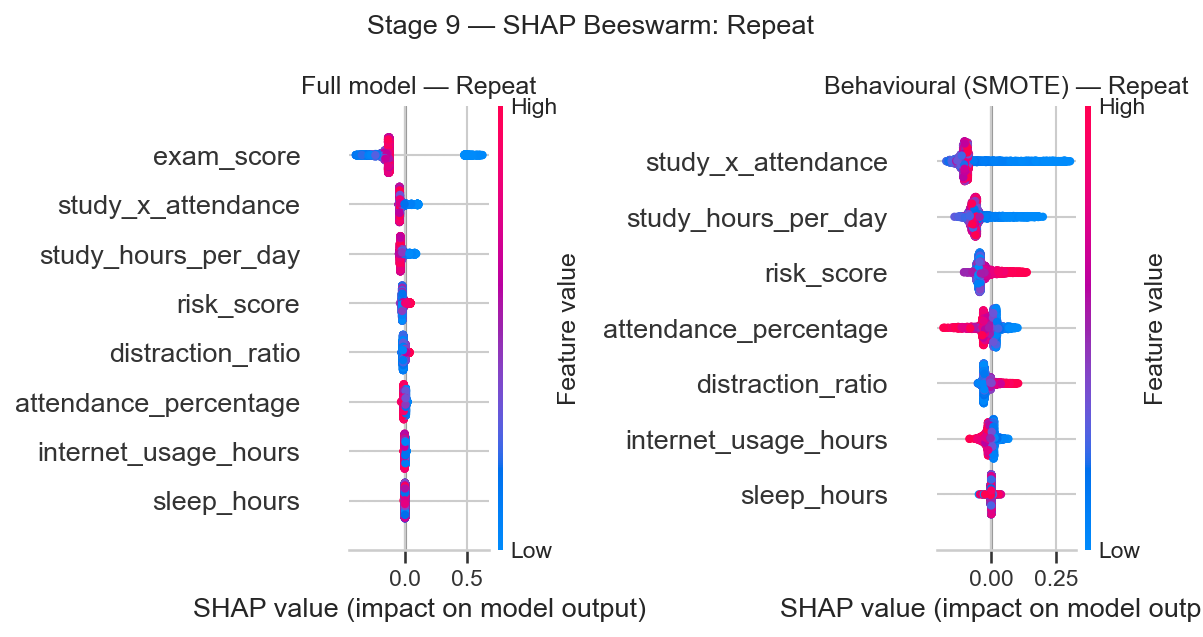

Saved: 06b_shap_repeat.png


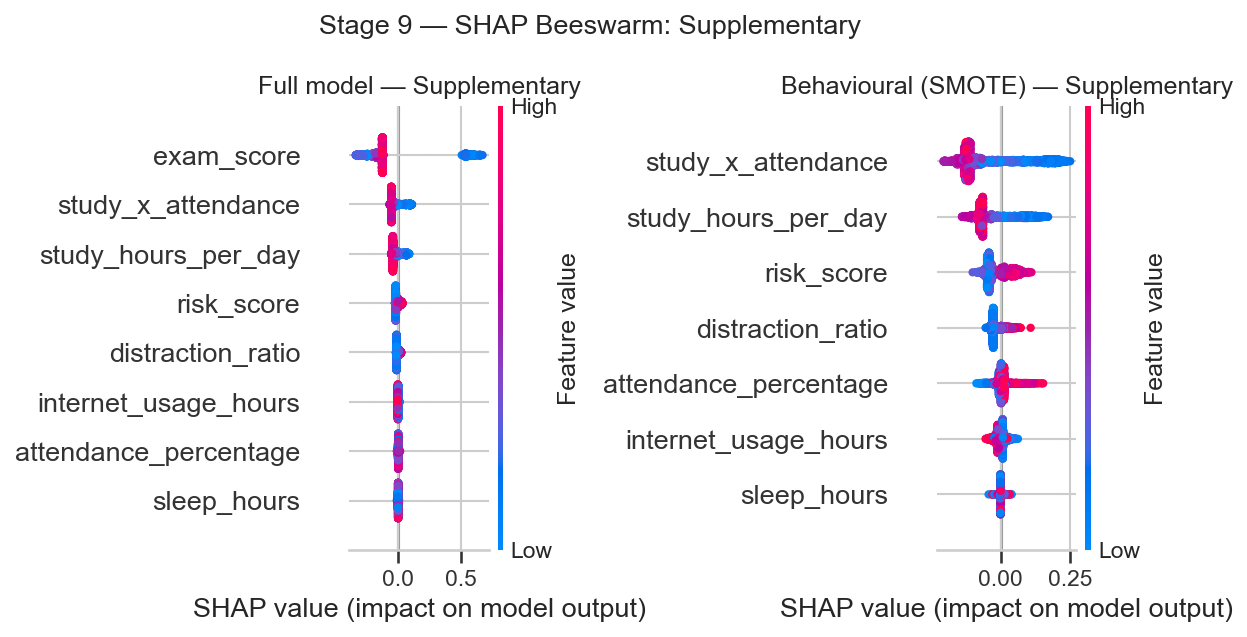

Saved: 06c_shap_supplementary.png


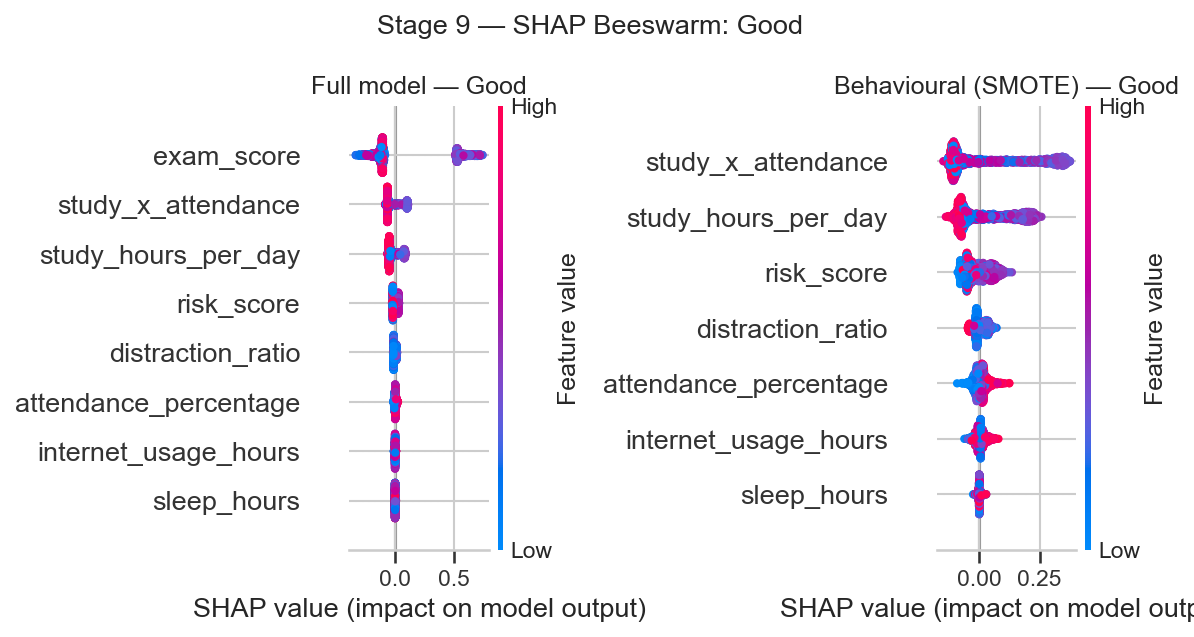

Saved: 06d_shap_good.png


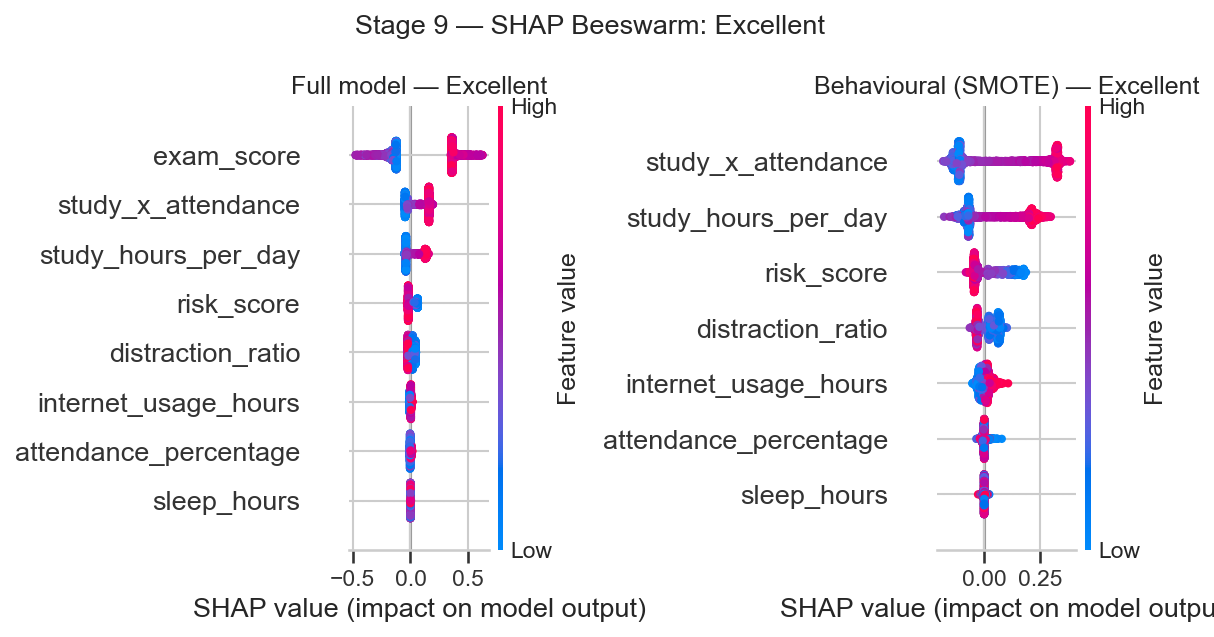

Saved: 06e_shap_excellent.png


In [22]:
for class_idx, band_name in enumerate(BAND_ORDER):
    fig, axes = plt.subplots(1, 2, figsize=(16, 5))
    plt.sca(axes[0])
    shap.summary_plot(sv_full[:, :, class_idx],  shap_sample_all, show=False)
    axes[0].set_title(f'Full model — {band_name}')
    plt.sca(axes[1])
    shap.summary_plot(sv_behav[:, :, class_idx], shap_sample_beh, show=False)
    axes[1].set_title(f'Behavioural (SMOTE) — {band_name}')
    plt.suptitle(f'Stage 9 — SHAP Beeswarm: {band_name}', fontsize=13)
    plt.tight_layout()
    fname = f'06{chr(98+class_idx)}_shap_{band_name.lower()}.png'
    plt.savefig(f'{REPORT_DIR}{fname}', bbox_inches='tight')
    plt.show()
    print(f'Saved: {fname}')

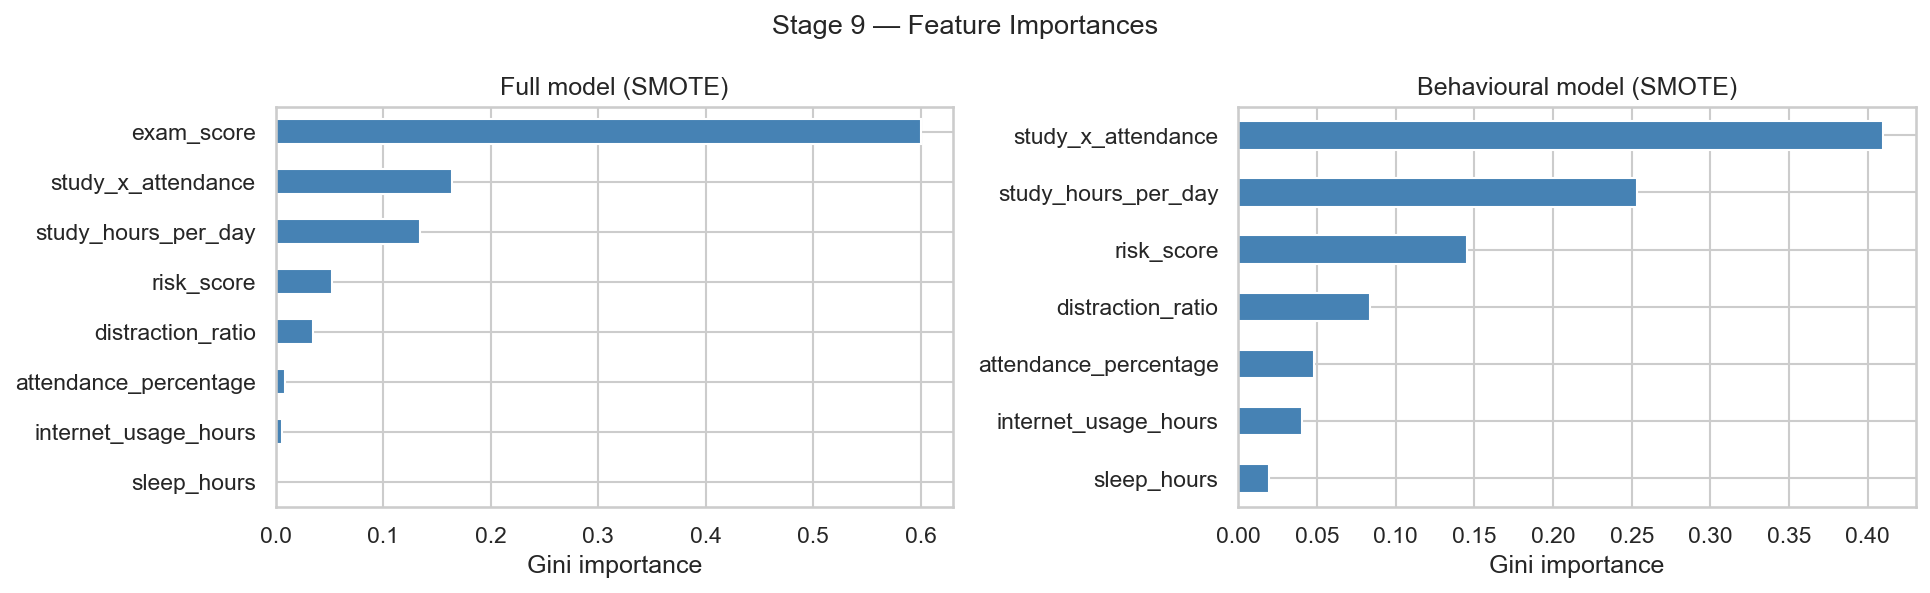

Saved: 06f_rf_importances.png

Behavioural model importances:
study_x_attendance       0.4099
study_hours_per_day      0.2536
risk_score               0.1453
distraction_ratio        0.0834
attendance_percentage    0.0479
internet_usage_hours     0.0404
sleep_hours              0.0195


In [23]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for ax, model, feats, title in [
    (axes[0], rf_full_sm,    ALL_FEATURES,   'Full model (SMOTE)'),
    (axes[1], rf_behav_final,BEHAV_FEATURES, 'Behavioural model (SMOTE)'),
]:
    imp = pd.Series(model.feature_importances_, index=feats).sort_values()
    imp.plot.barh(ax=ax, color='steelblue', edgecolor='white')
    ax.set_title(title)
    ax.set_xlabel('Gini importance')
plt.suptitle('Stage 9 — Feature Importances', fontsize=13)
plt.tight_layout()
plt.savefig(f'{REPORT_DIR}06f_rf_importances.png', bbox_inches='tight')
plt.show()
print('Saved: 06f_rf_importances.png')
print('\nBehavioural model importances:')
print(pd.Series(rf_behav_final.feature_importances_, index=BEHAV_FEATURES)
      .sort_values(ascending=False).round(4).to_string())

## Stage 10 — Save All Artefacts & Prediction Test

In [24]:
# Save all artefacts the app will need
scaler_full  = StandardScaler().fit(df[ALL_FEATURES])
scaler_behav = StandardScaler().fit(df[BEHAV_FEATURES])

joblib.dump(scaler_full,       f'{MODEL_DIR}scaler_full.pkl')
joblib.dump(scaler_behav,      f'{MODEL_DIR}scaler_behav.pkl')
joblib.dump(ALL_FEATURES,      f'{MODEL_DIR}all_feature_names.pkl')
joblib.dump(BEHAV_FEATURES,    f'{MODEL_DIR}behav_feature_names.pkl')
joblib.dump(BAND_ORDER,        f'{MODEL_DIR}band_order.pkl')
joblib.dump(BAND_TO_INT,       f'{MODEL_DIR}band_to_int.pkl')
joblib.dump(INT_TO_BAND,       f'{MODEL_DIR}int_to_band.pkl')
joblib.dump(assign_mzuni_band, f'{MODEL_DIR}rule_engine.pkl')
# rf_full_model.pkl and rf_behav_model.pkl already saved above

print('=== model_oversampled/ contents ===')
for fname in sorted(os.listdir(MODEL_DIR)):
    kb = os.path.getsize(f'{MODEL_DIR}{fname}') / 1024
    print(f'  {fname:<40} {kb:>8.0f} KB')

=== model_oversampled/ contents ===
  all_feature_names.pkl                           0 KB
  band_order.pkl                                  0 KB
  band_to_int.pkl                                 0 KB
  behav_feature_names.pkl                         0 KB
  feat_maxes.pkl                                  0 KB
  int_to_band.pkl                                 0 KB
  rf_behav_model.pkl                          93542 KB
  rf_full_model.pkl                           39660 KB
  rule_engine.pkl                                 0 KB
  scaler_behav.pkl                                1 KB
  scaler_full.pkl                                 1 KB


In [25]:
RECOMMENDATIONS = {
    'Repeat': {
        'student': [
            'Seek academic counselling immediately — do not wait until exams.',
            'Increase study hours to at least 4 hours per day.',
            'Attend every class — missing even one session compounds the risk.',
            'Reduce recreational internet usage to under 1 hour on study days.',
            'Form a study group with Good or Excellent band peers.',
        ],
        'lecturer': [
            'Flag for urgent one-on-one academic review.',
            'Escalate to the academic advisor or HOD immediately.',
            'Provide additional practice questions on foundational concepts.',
            'Schedule a mid-semester progress check-in.',
        ],
    },
    'Supplementary': {
        'student': [
            'You are close to the pass boundary — focused effort now can shift your outcome.',
            'Target the specific CA components where marks were lost.',
            'Attend all remaining classes without exception.',
            'Reduce internet usage on study days.',
            'Use office hours to get feedback on weak areas.',
        ],
        'lecturer': [
            'Provide supplementary practice materials and past questions.',
            'Schedule an office hours check-in.',
            'Monitor attendance closely over the next two weeks.',
        ],
    },
    'Good': {
        'student': [
            'You are on track — maintain your current study routine.',
            'Aim to add 30 minutes of study per day.',
            'Attempt past exam papers under timed conditions.',
            'Set a stretch target of the Excellent band.',
        ],
        'lecturer': [
            'Encourage with extension tasks or challenge questions.',
            'Suggest peer tutoring to reinforce knowledge.',
        ],
    },
    'Excellent': {
        'student': [
            'Outstanding — maintain your current habits.',
            'Consider mentoring peers in lower bands.',
            'Explore supplementary reading for advanced coursework.',
        ],
        'lecturer': [
            'Recognise this performance publicly where appropriate.',
            'Assign a peer mentorship role to extend impact.',
        ],
    },
}

def add_engineered_features(data: dict) -> dict:
    d = data.copy()
    d['study_x_attendance'] = d['study_hours_per_day'] * d['attendance_percentage'] / 100
    d['distraction_ratio']  = min(d['internet_usage_hours'] / (d['study_hours_per_day'] + 0.1), 10)
    study_norm    = d['study_hours_per_day']  / FEAT_MAXES['study_hours_per_day']
    attend_norm   = d['attendance_percentage'] / 100
    internet_norm = d['internet_usage_hours']  / FEAT_MAXES['internet_usage_hours']
    d['risk_score'] = (1-study_norm)*0.4 + (1-attend_norm)*0.4 + internet_norm*0.2
    return d

def predict_student(raw_data: dict, mode: str = 'full') -> dict:
    data = add_engineered_features(raw_data)
    if mode == 'full':
        band  = assign_mzuni_band(data['exam_score'])
        model = rf_full_sm
        feats = ALL_FEATURES
    else:
        band  = None
        model = rf_behav_final
        feats = BEHAV_FEATURES
    input_df   = pd.DataFrame([data])[feats]
    proba      = model.predict_proba(input_df)[0]
    pred_int   = model.predict(input_df)[0]
    pred_band  = INT_TO_BAND[pred_int]
    final_band = band if mode == 'full' else pred_band
    confidence = proba[BAND_TO_INT[final_band]] * 100
    exp    = shap.TreeExplainer(model)
    sv     = normalise_shap(np.array(exp.shap_values(input_df)), 1)
    sv_cls = sv[0, :, BAND_TO_INT[final_band]]
    drivers= pd.Series(np.abs(sv_cls), index=feats).sort_values(ascending=False)
    return {
        'mode':             mode,
        'band':             final_band,
        'ml_prediction':    pred_band,
        'confidence':       round(confidence, 1),
        'probabilities':    {b: round(proba[i]*100, 1) for i, b in enumerate(BAND_ORDER)},
        'top_drivers':      drivers.head(3).index.tolist(),
        'student_actions':  RECOMMENDATIONS[final_band]['student'],
        'lecturer_actions': RECOMMENDATIONS[final_band]['lecturer'],
    }

print('predict_student() ready.')

predict_student() ready.


In [26]:
test_students = [
    {'name': 'Alice — Repeat (full)',
     'mode': 'full',
     'data': {'study_hours_per_day':1.5,'attendance_percentage':42.0,
               'sleep_hours':5.0,'internet_usage_hours':7.0,'exam_score':22.0}},
    {'name': 'Bob — Supplementary (full)',
     'mode': 'full',
     'data': {'study_hours_per_day':2.5,'attendance_percentage':61.0,
               'sleep_hours':6.5,'internet_usage_hours':4.0,'exam_score':40.0}},
    {'name': 'Carol — Good (full)',
     'mode': 'full',
     'data': {'study_hours_per_day':4.0,'attendance_percentage':78.0,
               'sleep_hours':7.0,'internet_usage_hours':2.5,'exam_score':57.0}},
    {'name': 'David — Excellent (full)',
     'mode': 'full',
     'data': {'study_hours_per_day':6.5,'attendance_percentage':95.0,
               'sleep_hours':8.0,'internet_usage_hours':1.0,'exam_score':82.0}},
    {'name': 'Eve — Early warning (no exam score)',
     'mode': 'early',
     'data': {'study_hours_per_day':1.2,'attendance_percentage':38.0,
               'sleep_hours':5.0,'internet_usage_hours':8.0}},
]

for s in test_students:
    r = predict_student(s['data'], mode=s['mode'])
    print('=' * 64)
    print(f"Student  : {s['name']}")
    print(f"Mode     : {r['mode']}  |  Band: {r['band']}  |  ML: {r['ml_prediction']}")
    print(f"Confidence: {r['confidence']}%  |  Proba: {r['probabilities']}")
    print(f"Top drivers   : {r['top_drivers']}")
    print(f"Student action: {r['student_actions'][0]}")
    print(f"Lecturer action: {r['lecturer_actions'][0]}")
print('=' * 64)

Student  : Alice — Repeat (full)
Mode     : full  |  Band: Repeat  |  ML: Repeat
Confidence: 99.0%  |  Proba: {'Repeat': np.float64(99.0), 'Supplementary': np.float64(1.0), 'Good': np.float64(0.0), 'Excellent': np.float64(0.0)}
Top drivers   : ['exam_score', 'study_x_attendance', 'study_hours_per_day']
Student action: Seek academic counselling immediately — do not wait until exams.
Lecturer action: Flag for urgent one-on-one academic review.
Student  : Bob — Supplementary (full)
Mode     : full  |  Band: Supplementary  |  ML: Supplementary
Confidence: 97.9%  |  Proba: {'Repeat': np.float64(1.6), 'Supplementary': np.float64(97.9), 'Good': np.float64(0.5), 'Excellent': np.float64(0.0)}
Top drivers   : ['exam_score', 'study_x_attendance', 'study_hours_per_day']
Student action: You are close to the pass boundary — focused effort now can shift your outcome.
Lecturer action: Provide supplementary practice materials and past questions.
Student  : Carol — Good (full)
Mode     : full  |  Band: 

In [27]:
print('Batch test — 2,000 held-out students...')
results = []
for _, row in X_all_te.sample(2000, random_state=99).iterrows():
    raw = {f: row[f] for f in RAW_BEHAV + ['exam_score']}
    r   = predict_student(raw, mode='full')
    results.append({'true': INT_TO_BAND[y_test.loc[row.name]],
                    'predicted': r['band'], 'confidence': r['confidence']})

res_df   = pd.DataFrame(results)
accuracy = (res_df['true'] == res_df['predicted']).mean()
print(f'\nBatch accuracy : {accuracy*100:.1f}%')
print(f'Mean confidence: {res_df["confidence"].mean():.1f}%')
print(f'\nPer-band accuracy:')
for band in BAND_ORDER:
    sub = res_df[res_df['true'] == band]
    if len(sub):
        acc = (sub['true'] == sub['predicted']).mean()
        print(f'  {band:<15}: {acc*100:.1f}%  (n={len(sub)})')
res_df.to_csv(f'{REPORT_DIR}07_batch_test_results.csv', index=False)
print('\nSaved: 07_batch_test_results.csv')

Batch test — 2,000 held-out students...

Batch accuracy : 100.0%
Mean confidence: 99.0%

Per-band accuracy:
  Repeat         : 100.0%  (n=129)
  Supplementary  : 100.0%  (n=306)
  Good           : 100.0%  (n=708)
  Excellent      : 100.0%  (n=857)

Saved: 07_batch_test_results.csv


## Stage 11 — Final Summary

In [28]:
# Export intervention table
ranges = {'Repeat':'0-34%','Supplementary':'35-44%','Good':'45-64%','Excellent':'65-100%'}
rows = [{'Band':b,'Score range':ranges[b],
          'Student actions':' | '.join(RECOMMENDATIONS[b]['student'][:3]),
          'Lecturer actions':' | '.join(RECOMMENDATIONS[b]['lecturer'][:2])}
         for b in BAND_ORDER]
pd.DataFrame(rows).to_csv(f'{REPORT_DIR}08_intervention_recommendations.csv', index=False)
print('Saved: 08_intervention_recommendations.csv')

print('\n' + '='*70)
print('OVERSAMPLED PIPELINE COMPLETE — BSDS0322')
print('='*70)
print(f'Dataset              : {len(df):,} records')
print(f'SMOTE training size  : {len(X_beh_tr_sm):,} (from {len(X_beh_tr):,} original)')
print(f'Behavioural features : {BEHAV_FEATURES}')
print()
print('Model performance (behavioural, early warning):')
print(f'  Baseline F1 (macro)             : {f1_base:.4f}')
print(f'  Tuned SMOTE F1 (macro)          : {f1_tuned:.4f}')
print(f'  Final compressed F1 (macro)     : {f1_final:.4f}')
print(f'  Baseline Repeat recall          : {recall_repeat_base:.4f}')
print(f'  Final SMOTE Repeat recall       : {recall_repeat_final:.4f}')
print(f'  Repeat recall improvement       : +{(recall_repeat_final-recall_repeat_base)*100:.2f}%')
print()
print('Saved model artefacts:')
for f in sorted(os.listdir(MODEL_DIR)):
    kb = os.path.getsize(f'{MODEL_DIR}{f}') / 1024
    print(f'  {f:<40} {kb:>8.0f} KB')
print('='*70)
print('Ready for comparison against improved notebook. Build app next.')

Saved: 08_intervention_recommendations.csv

OVERSAMPLED PIPELINE COMPLETE — BSDS0322
Dataset              : 1,000,000 records
SMOTE training size  : 1,365,076 (from 800,000 original)
Behavioural features : ['study_hours_per_day', 'attendance_percentage', 'sleep_hours', 'internet_usage_hours', 'study_x_attendance', 'distraction_ratio', 'risk_score']

Model performance (behavioural, early warning):
  Baseline F1 (macro)             : 0.7327
  Tuned SMOTE F1 (macro)          : 0.7379
  Final compressed F1 (macro)     : 0.7360
  Baseline Repeat recall          : 0.7595
  Final SMOTE Repeat recall       : 0.6813
  Repeat recall improvement       : +-7.82%

Saved model artefacts:
  all_feature_names.pkl                           0 KB
  band_order.pkl                                  0 KB
  band_to_int.pkl                                 0 KB
  behav_feature_names.pkl                         0 KB
  feat_maxes.pkl                                  0 KB
  int_to_band.pkl                         

## Report Writing Guide — Oversampled Results

| File | Report Section |
|------|----------------|
| `01_smote_balance.png` | 5.2 — Justify SMOTE: show class imbalance before/after |
| `02_confusion_full.png` | 5.4 — Full model evaluation (oversampled) |
| `03_confusion_behav_comparison.png` | 5.4 — Baseline vs SMOTE improvement |
| `04_model_progression.csv` | 5.4 — Tuning summary table |
| `05_band_distribution.png` | 5.3 — Layer 1 bands |
| `06a_shap_global.png` | 5.3 — SHAP global importance |
| `06b–06e shap PNGs` | 5.3 — Per-band drivers |
| `07_batch_test_results.csv` | 5.4 — Generalisation test |
| `model_oversampled/` | Appendix — deployment artefacts |

**Key comparison to make in the report:**
Compare `04_model_progression.csv` from this notebook against `07_model_progression.csv`
from the improved notebook. The headline metric to highlight is **Repeat band recall** —
this is the most important number for a proactive intervention system.